# Workflow to calculate the BMI

input ( weight + height) --> BMI Calculator --> Output

In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [2]:
# Before Making any workflow we need to define the state graph. 
# The state graph defines the states and transitions between them. 
# It is a directed graph where nodes represent states and edges represent transitions.

class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float

In [3]:
# Python Function to calculate BMI

def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi,2)
    return state

In [4]:
# Before defining the graph we make a graph object
# in langGraph we can define a graph using the StateGraph class --> by giving it the state of our workflow

graph = StateGraph(BMIState)    # Register our graph

# Now we will add nodes to our graph
graph.add_node("calculate_bmi", calculate_bmi)

# Now we will add edges to our graph
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi", END)

# Now we will compile the Graph 
workflow = graph.compile()

In [5]:
# Now we will execute the graph

intial_state = {"weight_kg": 80, "height_m": 1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}


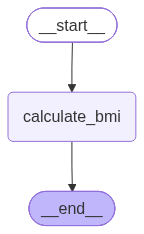

In [6]:
# Visualize the graph

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# UPDATE THE WORKFLOW

input ( weight + height) --> BMI Calculator --> BMI Label --> Output

In [7]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [8]:
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    bmi_label: str

In [9]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi,2)
    return state

def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['bmi_label'] = "Underweight"
    elif 18.5 <= bmi < 24.9:
        state['bmi_label'] = "Normal weight"
    elif 25 <= bmi < 29.9:
        state['bmi_label'] = "Overweight"
    else:
        state['bmi_label'] = "Obesity"
    return state

In [10]:
graph = StateGraph(BMIState)    # Register our graph

graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("label_bmi", label_bmi)

graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge("label_bmi", END)

workflow = graph.compile()

In [11]:
intial_state = {"weight_kg": 80, "height_m": 1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'bmi_label': 'Overweight'}


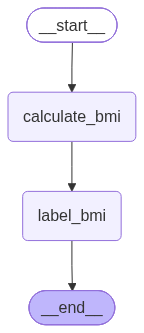

In [12]:
from IPython.display import Image
display(Image(workflow.get_graph().draw_mermaid_png())) 

# LLM Based Workflow

Start --> llm (question/answer) --> End 

In [13]:
from langgraph.graph import StateGraph , START , END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [14]:
load_dotenv()

True

In [15]:
model = ChatOpenAI()

In [16]:
class LLMState(TypedDict):
    Question_llm: str
    Answer_llm: str

In [17]:
def llm_qa(state: LLMState) -> LLMState:
    question = state['Question_llm']
    prompt = f"Answer the following question: {question}"
    answer = model.invoke(prompt).content
    state['Answer_llm'] = answer
    return state

In [18]:
graph = StateGraph(LLMState)

graph.add_node("llm_qa",llm_qa)

graph.add_edge(START,"llm_qa")
graph.add_edge("llm_qa", END)

workflow = graph.compile()

In [19]:
initial_state = {"Question_llm": "What is the capital of France?"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'Question_llm': 'What is the capital of France?', 'Answer_llm': 'The capital of France is Paris.'}


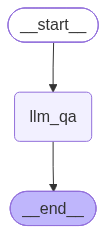

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# Prompt Chaining Workflow

Start --> llm(outline) --> llm(blog) --> End

In [21]:
from langgraph.graph import StateGraph , START , END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [23]:
class BlogState(TypedDict):
    Topic: str
    Outline: str
    Blog: str

In [25]:
load_dotenv()

True

In [26]:
model = ChatOpenAI()

In [29]:
def generate_outline(state:BlogState) -> BlogState:
    topic = state['Topic']
    prompt = f"Generate a detailed outline for a blog post on the topic: {topic}"
    outline = model.invoke(prompt).content
    state['Outline'] = outline
    return state

def generate_blog(state:BlogState) -> BlogState:
    outline = state['Outline']
    prompt = f"Generate a detailed blog post based on the following outline: {outline}"
    blog = model.invoke(prompt).content
    state['Blog'] = blog
    return state

In [30]:
graph = StateGraph(BlogState)

graph.add_node("generate_outline", generate_outline)
graph.add_node("generate_blog", generate_blog)

graph.add_edge(START,"generate_outline")
graph.add_edge("generate_outline", "generate_blog")
graph.add_edge("generate_blog", END)

workflow = graph.compile()

In [34]:
initial_state = {"Topic": "Marriage"}

final_state = workflow.invoke(initial_state)

print(final_state["Blog"])

Marriage is one of the oldest institutions in human society, often considered a cornerstone of stability and companionship. It is a legally and socially recognized union between two individuals, typically characterized by vows of commitment and love. In this blog post, we will explore the history, purpose, benefits, challenges, and importance of marriage in today's society.

Marriage has been practiced across cultures and time periods, with origins dating back to ancient civilizations. While the customs and rituals associated with marriage have evolved over time, the underlying principles of partnership and commitment remain constant. Changes in marriage laws and societal norms have also influenced the institution of marriage, reflecting shifts in attitudes towards gender roles, sexuality, and family structures.

The purpose of marriage serves many roles, including providing companionship and emotional support, procreation and raising a family, and obtaining financial and practical ben

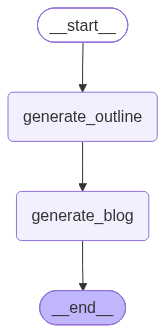

In [32]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# Prompt Chaining Updated Workflow

Start --> llm(outline) --> llm(blog) --> llm(evaluated) --> End

In [35]:
from langgraph.graph import StateGraph , START , END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [36]:
load_dotenv()

True

In [37]:
model = ChatOpenAI()

In [38]:
class ChatState(TypedDict):
    Topic: str
    outline: str
    blog: str
    evaluate: float

In [46]:
def generate_outline(state:ChatState) -> ChatState:
    topic = state['Topic']
    prompt = f"Generate a detailed outline for a blog post on the topic: {topic}"
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

def generate_blog(state:ChatState) -> ChatState:
    outline = state['outline']
    prompt = f"Generate a detailed blog post based on the following outline: {outline}"
    blog = model.invoke(prompt).content
    state['blog'] = blog
    return state

def evaluate_blog(state:ChatState) -> ChatState:
    blog = state['blog']
    prompt = f"Evaluate the following blog post and provide a score out of 10: {blog}"
    evaluation = model.invoke(prompt).content
    state['evaluate'] = evaluation
    return state

In [47]:
graph = StateGraph(ChatState)

graph.add_node("generate_outline", generate_outline)
graph.add_node("generate_blog", generate_blog)
graph.add_node("evaluate_blog", evaluate_blog)

graph.add_edge(START,"generate_outline")
graph.add_edge("generate_outline", "generate_blog")
graph.add_edge("generate_blog", "evaluate_blog")
graph.add_edge("evaluate_blog", END)

workflow = graph.compile()

In [48]:
initial_state = {"Topic": "Marriage"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'Topic': 'Marriage', 'outline': 'I. Introduction\n    A. Brief explanation of the importance of marriage\n    B. Overview of the different aspects of marriage to be discussed in the blog post\n\nII. The History of Marriage\n    A. Ancient practices of marriage\n    B. Evolution of marriage throughout history\n    C. Cultural differences in marriage customs\n\nIII. The Purpose of Marriage\n    A. Companionship and emotional support\n    B. Building a family and raising children\n    C. Legal and financial benefits of marriage\n\nIV. The Benefits of Marriage\n    A. Improved physical and mental health\n    B. Greater financial stability\n    C. Long-lasting emotional connection\n\nV. Challenges in Marriage\n    A. Communication issues\n    B. Conflicts and disagreements\n    C. Infidelity and trust issues\n\nVI. Tips for a Successful Marriage\n    A. Effective communication strategies\n    B. Conflict resolution techniques\n    C. Prioritizing quality time together\n\nVII. The Impact of

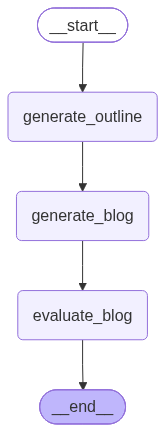

In [49]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())